# Computational cost summary (Reviewer 1, comment 3.5)

Summarize measured **wall-clock training time** and **peak GPU memory** (`torch.cuda.max_memory_allocated()`) for standard vs. AR scVI training on **L40S GPUs**.

Focus: blood-base scTab training with `atlas_count = 0`, $\alpha = 10^{-4}$, varying latent dimension $K$ and epoch count $T$ (matching the manuscript hyperparameter sweeps).

**Outputs** (written to `eval_scripts/outputs/computational_cost/`):
- `computational_cost_by_config.csv` — per-configuration mean $\pm$ std
- `computational_cost_supplementary_table.tex` — LaTeX table for Supplementary Materials
- `computational_cost_plot.png` — wall-clock and memory vs. configuration

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eval_scripts" else NOTEBOOK_DIR

# Prefer the full profiling export used in the rebuttal (repo copy may be a stub).
CSV_CANDIDATES = [
    REPO_ROOT / "rebuttal_analysis/outputs/resources_different_k.csv",
    Path(
        "/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/resources_different_k.csv"
    ),
    REPO_ROOT / "result/train/resources.csv",
]


def _csv_score(path: Path) -> int:
    if not path.exists():
        return -1
    tmp = pd.read_csv(path)
    if "atlas_count" not in tmp.columns:
        return 0
    tmp["atlas_count"] = tmp["atlas_count"].astype(int)
    return int((tmp["atlas_count"] == 0).sum())


CSV_PATH = max(CSV_CANDIDATES, key=_csv_score)
OUT_DIR = NOTEBOOK_DIR / "outputs" / "computational_cost"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading: {CSV_PATH} ({_csv_score(CSV_PATH)} atlas_count=0 rows)")
print(f"Writing: {OUT_DIR}")

Reading: /Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/resources_different_k.csv (40 atlas_count=0 rows)
Writing: /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost


In [6]:
df = pd.read_csv(CSV_PATH)
if "date" in df.columns:
    df = df.drop(columns=["date"])

# Normalize dtypes
df["AR"] = df["AR"].map({True: True, False: False, "True": True, "False": False})
for col in ["latent_dim", "num_epoch", "seed", "atlas_count", "batch_size"]:
    df[col] = df[col].astype(int)
df["alpha"] = df["alpha"].astype(float)

df.head()

,id,model_name,data,AR,ood,variable_con,con_percent,lr,weight_decay,batch_size,latent_dim,alpha,num_epoch,seed,atlas_count,training_time,peak_mem_gb
0,bloodbase-0atlas-ART-lr5e-05-wd5e-05-bs4096-ld...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,0,347.333696,1.076622
1,bloodbase-1atlas-ART-lr5e-05-wd5e-05-bs4096-ld...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,1,348.132296,1.071720
2,bloodbase-10atlas-ART-lr5e-05-wd5e-05-bs4096-l...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,10,350.606514,1.071720
3,bloodbase-100atlas-ART-lr5e-05-wd5e-05-bs4096-...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,100,342.887977,1.071720
4,bloodbase-1000atlas-ART-lr5e-05-wd5e-05-bs4096...,scvi,sctab,True,True,False,1.0,0.00005,0.00005,4096,64,0.0001,150,50,1000,340.333302,1.066817


In [7]:
# Main-text / supplementary comparison settings
FILTER = {
    "model_name": "scvi",
    "data": "sctab",
    "atlas_count": 0,
    "alpha": 0.0001,
    "batch_size": 4096,
}

# Configurations varied in the manuscript (K, T)
CONFIGS = [(64, 150), (64, 600), (32, 300), (128, 300)]

mask = np.ones(len(df), dtype=bool)
for col, val in FILTER.items():
    mask &= df[col] == val
cost_df = df.loc[mask].copy()

print(f"Filtered rows: {len(cost_df)} (expect 40 = 4 configs x 2 methods x 5 seeds)")
if len(cost_df) < 8:
    raise ValueError(
        f"Too few rows ({len(cost_df)}) after filtering. "
        f"Check CSV_PATH={CSV_PATH} — use resources_different_k.csv, not a stub resources.csv."
    )

cost_df.groupby(["latent_dim", "num_epoch", "AR"]).size()

Filtered rows: 40 (expect 40 = 4 configs x 2 methods x 5 seeds)


latent_dim  num_epoch  AR   
32          300        False    5
                       True     5
64          150        False    5
                       True     5
            600        False    5
                       True     5
128         300        False    5
                       True     5
dtype: int64

In [8]:
def summarize_config(sub: pd.DataFrame, method: str) -> dict | None:
    row = sub[sub["AR"] == (method == "AR")]
    if row.empty:
        return None
    return {
        "method": method,
        "time_s_mean": row["training_time"].mean(),
        "time_s_std": row["training_time"].std(ddof=1),
        "mem_gb_mean": row["peak_mem_gb"].mean(),
        "mem_gb_std": row["peak_mem_gb"].std(ddof=1),
        "n_seeds": len(row),
    }


rows = []
for latent_dim, num_epoch in CONFIGS:
    sub = cost_df[(cost_df["latent_dim"] == latent_dim) & (cost_df["num_epoch"] == num_epoch)]
    if sub.empty:
        print(f"Warning: no data for K={latent_dim}, T={num_epoch}")
        continue
    for method in ["Standard", "AR"]:
        rec = summarize_config(sub, method)
        if rec is None:
            print(f"Warning: missing {method} for K={latent_dim}, T={num_epoch}")
            continue
        rec.update({"latent_dim": latent_dim, "num_epoch": num_epoch})
        rows.append(rec)

summary = pd.DataFrame(rows)
if summary.empty:
    raise ValueError("No configuration summaries were produced; check CSV and CONFIGS.")

# Relative wall-clock (AR / Standard) per configuration
ratio_rows = []
for (ld, ep), grp in summary.groupby(["latent_dim", "num_epoch"]):
    methods = set(grp["method"])
    if methods != {"Standard", "AR"}:
        print(f"Warning: skipping ratio for K={ld}, T={ep} (methods={methods})")
        continue
    std_time = grp.loc[grp["method"] == "Standard", "time_s_mean"].iloc[0]
    ar_time = grp.loc[grp["method"] == "AR", "time_s_mean"].iloc[0]
    ratio_rows.append({"latent_dim": ld, "num_epoch": ep, "rel_time": ar_time / std_time})

ratio_df = pd.DataFrame(ratio_rows)
if ratio_df.empty:
    raise ValueError("Could not compute any AR/Standard time ratios.")

display_cols = [
    "latent_dim", "num_epoch", "method", "time_s_mean", "time_s_std",
    "mem_gb_mean", "mem_gb_std", "n_seeds",
]
summary[display_cols].round(2)

,latent_dim,num_epoch,method,time_s_mean,time_s_std,mem_gb_mean,mem_gb_std,n_seeds
0,64,150,Standard,143.36,2.08,1.12,0.04,5
1,64,150,AR,349.82,6.36,1.08,0.00,5
2,64,600,Standard,559.73,9.40,1.25,0.00,5
3,64,600,AR,1979.60,858.67,1.13,0.00,5
4,32,300,Standard,280.90,1.78,1.17,0.00,5
5,32,300,AR,680.88,9.23,1.08,0.01,5
6,128,300,Standard,283.56,2.78,1.19,0.00,5
7,128,300,AR,810.32,9.13,1.11,0.01,5


In [9]:
def fmt_pm(mean, std, digits=0):
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


summary.to_csv(OUT_DIR / "computational_cost_by_config.csv", index=False)
ratio_df.to_csv(OUT_DIR / "computational_cost_time_ratios.csv", index=False)

latex = [
    "\\begin{table}[t]",
    "\\centering",
    "\\caption{Training wall-clock time and peak GPU memory for standard and AR scVI training. "
    "Measurements were recorded on L40S GPUs using \\texttt{torch.cuda.max\\_memory\\_allocated()}. "
    "Blood-base scTab training with no atlas cells (\\texttt{atlas\\_count=0}), $\\alpha=10^{-4}$, "
    "batch size 4096; mean $\\pm$ s.d. over five random seeds.}",
    "\\label{tab:computational_cost}",
    "\\begin{tabular}{cc l cc c}",
    "\\toprule",
    "$K$ & $T$ & Method & Time (s) & Peak mem (GB) & Rel. time \\\\",
    "\\midrule",
]

for (ld, ep), grp in summary.groupby(["latent_dim", "num_epoch"]):
    if set(grp["method"]) != {"Standard", "AR"}:
        continue
    std = grp[grp["method"] == "Standard"].iloc[0]
    ar = grp[grp["method"] == "AR"].iloc[0]
    rel = ar["time_s_mean"] / std["time_s_mean"]
    latex.append(
        f"{ld} & {ep} & Standard & {fmt_pm(std['time_s_mean'], std['time_s_std'])} & "
        f"{std['mem_gb_mean']:.2f} & 1.00 \\\\"
    )
    latex.append(
        f"{ld} & {ep} & AR & {fmt_pm(ar['time_s_mean'], ar['time_s_std'])} & "
        f"{ar['mem_gb_mean']:.2f} & {rel:.2f}$\\times$ \\\\"
    )

latex += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
(OUT_DIR / "computational_cost_supplementary_table.tex").write_text("\n".join(latex))

print("Saved:")
print(" ", OUT_DIR / "computational_cost_by_config.csv")
print(" ", OUT_DIR / "computational_cost_supplementary_table.tex")

Saved:
  /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost/computational_cost_by_config.csv
  /Users/zeinab/Documents/MSR_internship/project/sc-AR-github-repo/sc-AR/eval_scripts/outputs/computational_cost/computational_cost_supplementary_table.tex


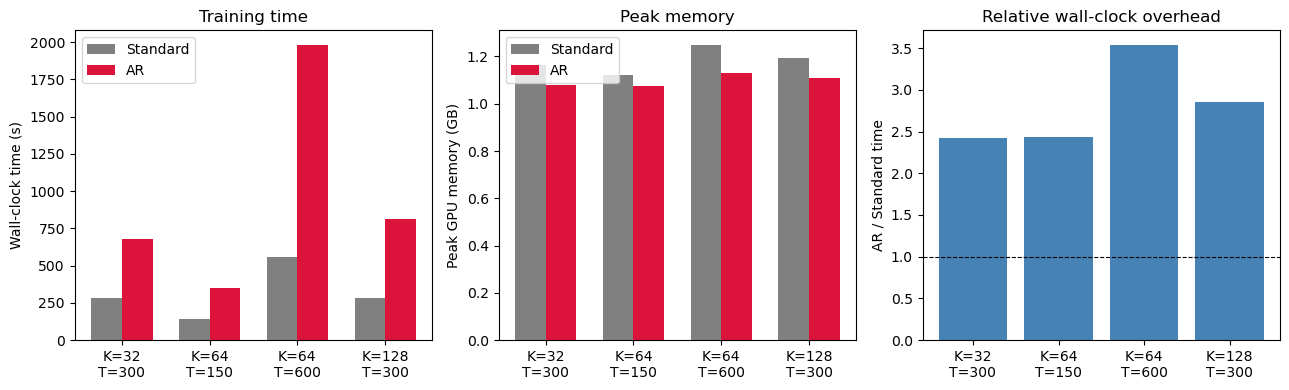

In [10]:
plot_configs = [
    (int(ld), int(ep))
    for ld, ep in summary[["latent_dim", "num_epoch"]].drop_duplicates().itertuples(index=False)
]
plot_configs = sorted(plot_configs, key=lambda x: (x[0], x[1]))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

labels = [f"K={ld}\nT={ep}" for ld, ep in plot_configs]
x = np.arange(len(plot_configs))
width = 0.35


def _metric(ld, ep, method, col):
    row = summary[
        (summary.latent_dim == ld)
        & (summary.num_epoch == ep)
        & (summary.method == method)
    ]
    return float(row[col].iloc[0])


std_times = [_metric(ld, ep, "Standard", "time_s_mean") for ld, ep in plot_configs]
ar_times = [_metric(ld, ep, "AR", "time_s_mean") for ld, ep in plot_configs]
std_mem = [_metric(ld, ep, "Standard", "mem_gb_mean") for ld, ep in plot_configs]
ar_mem = [_metric(ld, ep, "AR", "mem_gb_mean") for ld, ep in plot_configs]

axes[0].bar(x - width / 2, std_times, width, label="Standard", color="gray")
axes[0].bar(x + width / 2, ar_times, width, label="AR", color="crimson")
axes[0].set_ylabel("Wall-clock time (s)")
axes[0].set_xticks(x, labels)
axes[0].legend()
axes[0].set_title("Training time")

axes[1].bar(x - width / 2, std_mem, width, label="Standard", color="gray")
axes[1].bar(x + width / 2, ar_mem, width, label="AR", color="crimson")
axes[1].set_ylabel("Peak GPU memory (GB)")
axes[1].set_xticks(x, labels)
axes[1].legend()
axes[1].set_title("Peak memory")

rel_by_config = {
    (int(r.latent_dim), int(r.num_epoch)): float(r.rel_time)
    for r in ratio_df.itertuples(index=False)
}
rel_vals = [rel_by_config[(ld, ep)] for ld, ep in plot_configs]

axes[2].bar(x, rel_vals, color="steelblue")
axes[2].axhline(1.0, color="k", ls="--", lw=0.8)
axes[2].set_ylabel("AR / Standard time")
axes[2].set_xticks(x, labels)
axes[2].set_title("Relative wall-clock overhead")

plt.tight_layout()
fig.savefig(OUT_DIR / "computational_cost_plot.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# Discussion-ready summary (main paper config: K=64, T=150)
main = summary[(summary.latent_dim == 64) & (summary.num_epoch == 150)]
if len(main) != 2:
    raise ValueError("Expected Standard and AR rows for K=64, T=150.")

std = main[main.method == "Standard"].iloc[0]
ar = main[main.method == "AR"].iloc[0]
rel_main = ar.time_s_mean / std.time_s_mean
rel_min, rel_max = ratio_df.rel_time.min(), ratio_df.rel_time.max()

print("Discussion snippet:")
print(
    f"Although AR did not increase peak GPU memory relative to standard training, computing "
    f"resampling weights modestly increased wall-clock time. On L40S GPUs and blood-base scTab "
    f"training (atlas_count=0, five seeds), AR required {rel_min:.1f}–{rel_max:.1f}× longer than "
    f"standard training depending on latent dimension and epoch count—for example, "
    f"{ar.time_s_mean:.0f} ± {ar.time_s_std:.0f} s vs. {std.time_s_mean:.0f} ± {std.time_s_std:.0f} s "
    f"at K=64 and T=150 ({rel_main:.2f}×)—while peak memory remained essentially unchanged "
    f"(≈ {std.mem_gb_mean:.2f} vs. {ar.mem_gb_mean:.2f} GB; Supplementary Table X)."
)

Discussion snippet:
Although AR did not increase peak GPU memory relative to standard training, computing resampling weights modestly increased wall-clock time. On L40S GPUs and blood-base scTab training (atlas_count=0, five seeds), AR required 2.4–3.5× longer than standard training depending on latent dimension and epoch count—for example, 350 ± 6 s vs. 143 ± 2 s at K=64 and T=150 (2.44×)—while peak memory remained essentially unchanged (≈ 1.12 vs. 1.08 GB; Supplementary Table X).


## Optional: pairwise overhead across all atlas counts

The block below reproduces the seed-level AR vs. standard pairing used in round-1 exploratory analysis (all atlas counts included).

In [12]:
group_cols = [
    "model_name", "ood", "variable_con", "con_percent", "lr", "weight_decay",
    "batch_size", "latent_dim", "alpha", "num_epoch", "seed", "atlas_count",
]

records = []
for _, row in df[df["AR"] == True].iterrows():
    match = df[df["AR"] == False]
    for col in group_cols:
        match = match[match[col] == row[col]]
    if len(match) != 1:
        continue
    false_time = float(match["training_time"].iloc[0])
    true_time = float(row["training_time"])
    records.append({
        "latent_dim": int(row["latent_dim"]),
        "num_epoch": int(row["num_epoch"]),
        "atlas_count": int(row["atlas_count"]),
        "pct_time": (true_time - false_time) / false_time * 100,
        "diff_mem_gb": float(row["peak_mem_gb"] - match["peak_mem_gb"].iloc[0]),
    })

pairwise = pd.DataFrame(records)
print("Pairwise time overhead (%), atlas_count=0 only:")
display(
    pairwise[pairwise.atlas_count == 0]
    .groupby(["latent_dim", "num_epoch"])["pct_time"]
    .agg(["mean", "median", "std"])
    .round(1)
)

Pairwise time overhead (%), atlas_count=0 only:


mean  median    std
latent_dim num_epoch                      
32         300        142.4   142.5    4.1
64         150        144.0   143.0    4.6
           600        253.1   152.4  150.0
128        300        185.8   184.4    3.5